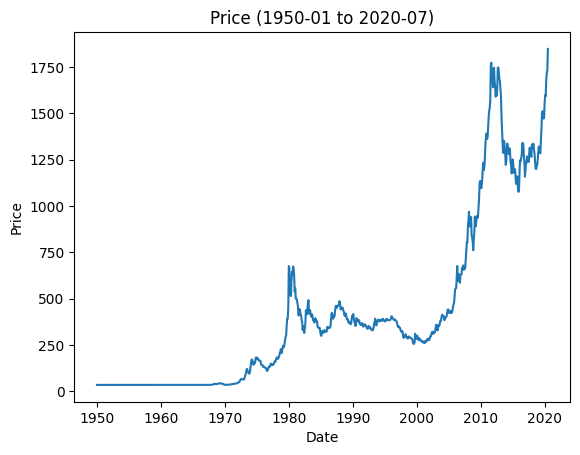

保存しました：monthly_1950-01_2020-07.csv


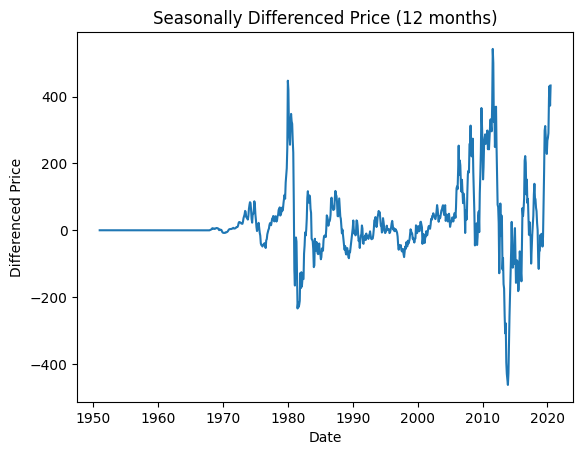

TypeError: float() argument must be a string or a real number, not 'Timestamp'

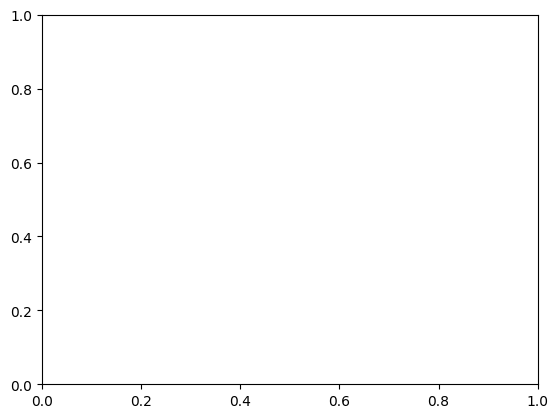

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- 読み込み（アップロードファイル）----
df = pd.read_csv("monthly.csv")

# ---- 日付変換 ----
df["Date"] = pd.to_datetime(df["Date"])

# ---- 期間指定：1950-01 ～ 2020-07 ----
start = pd.Timestamp("1950-01-01")
end   = pd.Timestamp("2020-07-01")
df_period = df[(df["Date"] >= start) & (df["Date"] <= end)].copy()

# ---- プロット ----
plt.plot(df_period["Date"], df_period["Price"])
plt.title("Price (1950-01 to 2020-07)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# ---- CSV 保存 ----
df_period.to_csv("monthly_1950-01_2020-07.csv", index=False, encoding="utf-8-sig")
print("保存しました：monthly_1950-01_2020-07.csv")

import pandas as pd
import matplotlib.pyplot as plt

# df_period がすでに期間フィルタ済みとする
# Date, Price の2列 → Price にだけ季節差分

# ---- seasonal difference (12 months) ----
differenced = df_period.copy()
differenced["Price"] = df_period["Price"].diff(12)

# ---- 最初の12行は NaN なので削除 ----
differenced = differenced.iloc[12:].reset_index(drop=True)

# ---- 保存 ----
differenced.to_csv("seasonally_adjusted.csv", index=False, encoding="utf-8-sig")

# ---- プロット ----
plt.plot(differenced["Date"], differenced["Price"])
plt.title("Seasonally Differenced Price (12 months)")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.show()

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df)
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# ---- 読み込み ----
df = pd.read_csv("monthly.csv")

# ---- 日付変換 ----
df["Date"] = pd.to_datetime(df["Date"])

# ---- 期間指定：1950-01 ～ 2020-07 ----
start = pd.Timestamp("1950-01-01")
end   = pd.Timestamp("2020-07-01")
df_period = df[(df["Date"] >= start) & (df["Date"] <= end)].copy()

# ---- 元データのプロット ----
plt.figure(figsize=(10, 4))
plt.plot(df_period["Date"], df_period["Price"])
plt.title("Price (1950-01 to 2020-07)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# ---- CSV 保存 ----
df_period.to_csv("monthly_1950-01_2020-07.csv", index=False, encoding="utf-8-sig")
print("保存しました：monthly_1950-01_2020-07.csv")

# ---- seasonal difference (12 months) ----
differenced = df_period.copy()
differenced["Price"] = df_period["Price"].diff(12)

# ---- NaN 削除 ----
differenced = differenced.dropna().reset_index(drop=True)

# ---- 保存 ----
differenced.to_csv("seasonally_adjusted.csv", index=False, encoding="utf-8-sig")
print("保存しました：seasonally_adjusted.csv")

# ---- 季節差分後のプロット ----
plt.figure(figsize=(10, 4))
plt.plot(differenced["Date"], differenced["Price"])
plt.title("Seasonally Differenced Price (12 months)")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.show()

# ---- ACF ----
plt.figure(figsize=(8, 4))
plot_acf(differenced["Price"], lags=40)
plt.title("ACF of Seasonally Differenced Price")
plt.show()